In [ ]:
# Dependencies
import sys
import os
import signal

print("Installing dependencies...")

# 1. Install dependencies
#    Added: bitsandbytes (for 4-bit quantization to fit Giga on T4/A100)
#    Added: accelerate (required for device_map="auto")
#    Added: autoawq (for running AWQ quantized LLMs in Phase 3)
!{sys.executable} -m pip install -q "numpy<2.0" qdrant-client sentence-transformers FlagEmbedding matplotlib scikit-learn pandas requests tqdm einops pyarrow accelerate ipywidgets datasets bitsandbytes autoawq

# 2. Check imports to see if a Restart is required
try:
    import numpy as np
    import pandas as pd
    import bitsandbytes
    print(f"Numpy Version: {np.__version__}")
    print(f"Pandas Version: {pd.__version__}")

    # Simple check: If we can't create a DataFrame, we are doomed and must restart.
    df_test = pd.DataFrame({"a": [1, 2, 3]})
    print("Dependency Check Passed.")

except Exception as e:
    print(f"Dependency Mismatch Detected ({e}). Restarting Kernel automatically...")
    # Restart the environment
    os.kill(os.getpid(), 9)

import torch
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"\nGPU Available: {props.name}")
    print(f"   VRAM: {props.total_memory / 1024**3:.2f} GB")
    print(f"   CUDA Capabilities: {props.major}.{props.minor}")

    if props.total_memory / 1024**3 < 20:
        print("WARNING: You are running on a GPU with < 20GB VRAM (likely T4).")
        print("   The 'Giga' model naturally requires ~30GB+ or ~15GB in FP16.")
        print("   We will attempt to load it in 4-bit mode to fit.")
else:
    print("\nNo GPU detected. This benchmark is designed for T4/A100/H100 GPUs.")
    print("   If you have allocated a GPU, please check 'Runtime > Change runtime type'.")

Installing dependencies...
Numpy Version: 1.26.4
Pandas Version: 2.2.2
Dependency Check Passed.

GPU Available: NVIDIA A100-SXM4-40GB
   VRAM: 39.56 GB
   CUDA Capabilities: 8.0


In [8]:
# Data Pipeline
import json
import os
import shutil
import pandas as pd
from tqdm.auto import tqdm
from typing import List, Dict

# Paths
LOCAL_DATA_DIR = "sample_data"
LOCAL_FILENAME = "train.jsonl"
# We check two locations: data/train.jsonl and ./train.jsonl
TARGET_PATH_1 = os.path.join(LOCAL_DATA_DIR, LOCAL_FILENAME)
TARGET_PATH_2 = LOCAL_FILENAME

# Create data dir just in case
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

docs = []
final_file_path = None

print("Searching for dataset...")

# 1. Check locations
if os.path.exists(TARGET_PATH_1):
    print(f"Found in data folder: {TARGET_PATH_1}")
    final_file_path = TARGET_PATH_1
elif os.path.exists(TARGET_PATH_2):
    print(f"Found in root: {TARGET_PATH_2}")
    final_file_path = TARGET_PATH_2
    # OPTIONAL: Copy to data folder for organization, but DO NOT MOVE/DELETE
    # shutil.copy(TARGET_PATH_2, TARGET_PATH_1)
else:
    print("Local file 'train.jsonl' NOT found.")
    print("STOPPING: User requested strict usage of local data.")
    print("ACTION REQUIRED: Upload 'train.jsonl' to Colab (Root or 'data' folder).")
    raise FileNotFoundError("Missing required dataset train.jsonl")

# 2. Read File
if final_file_path:
    try:
        print(f"Reading from: {final_file_path}")
        with open(final_file_path, 'r', encoding='utf-8') as f:
            for i, line in tqdm(enumerate(f), desc="Reading JSONL"):
                if not line.strip(): continue
                try:
                    row = json.loads(line)
                    # Robust Field Mapping
                    inp = row.get('input') or row.get('question') or row.get('instruction')
                    out = row.get('output') or row.get('answer') or row.get('response')
                    if inp and out:
                        docs.append({"id": i, "input": inp, "output": out})
                except: continue

        if not docs:
             raise ValueError("File was loaded but contained 0 valid records.")

        print(f"Loaded {len(docs)} documents from local file.")

    except Exception as e:
        print(f"Failed to read local file: {e}")
        raise e

print(f"\nDATA READY: {len(docs)} documents prepared for benchmarking.")

Searching for dataset...
Found in data folder: sample_data/train.jsonl
Reading from: sample_data/train.jsonl


Reading JSONL: 0it [00:00, ?it/s]

Loaded 21325 documents from local file.

DATA READY: 21325 documents prepared for benchmarking.


In [ ]:
# The Benchmark Class
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm
import uuid
import torch
import numpy as np
from typing import List, Dict

class RAGExperiment:
    def __init__(self, model_id: str):
        # FORCE GPU if available, otherwise WARN
        if torch.cuda.is_available():
            self.device = "cuda"
            props = torch.cuda.get_device_properties(0)
            print(f"GPU Mode Active: {props.name}")
            try:
                # Enable TF32 for Ampere (A100) and Hopper (H100) GPUs for significant speedup
                torch.set_float32_matmul_precision('high')
                print("   TF32 Precision Enabled (H100/A100 optimization)")
            except:
                pass
        else:
            self.device = "cpu"
            print(" CPU Mode Active (WARNING: Slower execution)")

        self.model_id = model_id
        self.model_name = model_id  # Fix for AttributeError in Phase 2

        print(f" Initializing Model: {model_id} on {self.device}")

        # Load Model locally (downloads to ~/.cache/huggingface first time)
        # trust_remote_code=True is required for custom architectures like Giga
        self.encoder = SentenceTransformer(model_id, device=self.device, trust_remote_code=True)

        # In-memory Qdrant (Runs locally in RAM, no server required)
        self.client = QdrantClient(":memory:")
        self.collection_name = "benchmark_collection"

    def index(self, documents: List[Dict], batch_size: int = 64): # Increased batch size for High-End GPU
        print(f"Indexing {len(documents)} documents...")

        # Determine Vector Size
        # Run warm-up encoding
        sample_vec = self.encoder.encode(["test"], show_progress_bar=False)
        if hasattr(sample_vec, "tolist"): # numpy check
             sample_vec = sample_vec[0]
        else:
             sample_vec = sample_vec[0]

        vector_size = len(sample_vec)
        print(f"   Vector Dimension: {vector_size}")

        self.client.recreate_collection(
            collection_name=self.collection_name,
            vectors_config=VectorParams(size=vector_size, distance=Distance.COSINE)
        )

        # Batch Upsert
        points = []
        for i in tqdm(range(0, len(documents), batch_size), desc="Indexing"):
            batch = documents[i : i+batch_size]
            texts = [str(d['output']) for d in batch]

            # Encode on GPU
            vectors = self.encoder.encode(texts, batch_size=batch_size, show_progress_bar=False, convert_to_numpy=True)

            for j, doc in enumerate(batch):
                point_id = str(uuid.uuid5(uuid.NAMESPACE_DNS, str(doc['id'])))
                points.append(PointStruct(id=point_id, vector=vectors[j].tolist(), payload=doc))

            self.client.upsert(self.collection_name, points)
            points = []

    def retrieve(self, query: str, top_k: int = 5):
        query_vector = self.encoder.encode([query], show_progress_bar=False)[0]

        # Compatible Retrieval for All Qdrant Versions
        # Recent versions dropped 'search', older ones don't have 'query_points' locally
        try:
             # Try New Unified API first (v1.10+)
            hits = self.client.query_points(
                self.collection_name,
                query=query_vector,
                limit=top_k
            ).points
        except (AttributeError, TypeError):
             # Fallback to Old API
            hits = self.client.search(
                self.collection_name,
                query_vector=query_vector,
                limit=top_k
            )

        return hits

In [ ]:
# Experiment Phase 1 (Embedding Battle)
from sklearn.metrics import ndcg_score
from tqdm.auto import tqdm
import gc # Import garbage collector

# --- Settings for H100 Benchmarking ---
DOC_LIMIT = 20000   # Maxing out to 20k as requested
QUERY_LIMIT = 2000  # Increased query count for robust stats
TOP_K = 3

# Safety check if we have enough docs
total_docs_loaded = len(docs)
DOC_LIMIT = min(DOC_LIMIT, total_docs_loaded)
QUERY_LIMIT = min(QUERY_LIMIT, total_docs_loaded)

subset_docs = docs[:DOC_LIMIT]
subset_queries = docs[:QUERY_LIMIT]

print(f"Starting H100 Benchmark on {len(subset_docs)} Documents & {len(subset_queries)} Queries")

results = {}

def calculate_metrics(hits, correct_id):
    # Debug: Check if IDs are strings/ints consistency
    retrieved_ids = [str(h.payload['id']) for h in hits]
    target = str(correct_id)

    # Recall
    recall = 1 if target in retrieved_ids else 0

    # MRR
    try:
        rank = retrieved_ids.index(target) + 1
        mrr = 1.0 / rank
    except ValueError:
        mrr = 0.0

    # NDCG
    relevance = [1 if pid == target else 0 for pid in retrieved_ids]
    if sum(relevance) == 0:
        ndcg = 0.0
    else:
        ideal = sorted(relevance, reverse=True)
        ndcg = ndcg_score([ideal], [relevance])

    return recall, mrr, ndcg

MODELS = [
    "infgrad/stella-base-en-v2",       # Fast Baseline
    "ai-sage/Giga-Embeddings-instruct" # SOTA Heavyweight
]

best_model_instance = None
best_mrr_score = -1.0

for model_name in MODELS:
    # Aggressive cleanup memory before loading new model
    if 'exp' in locals() and exp is not None:
        if hasattr(exp, 'encoder') and exp.encoder is not None:
             # Try to free memory
             del exp.encoder
        del exp

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    try:
        exp = RAGExperiment(model_name)

        # Check if GPU is active, if not, raise an error to halt.
        if exp.device == "cpu":
             raise RuntimeError(f"GPU not detected for model '{model_name}'. Please ensure a GPU runtime is selected. Cannot proceed with benchmarking on CPU.")

        # Adjust batch size based on model
        current_batch_size = 128
        if "Giga" in model_name:
            current_batch_size = 16 # Safe conservative batch size for Giga on potentially smaller GPUs

        print(f"   Using Batch Size: {current_batch_size}")
        exp.index(subset_docs, batch_size=current_batch_size)

        metrics = {"Recall": [], "MRR": [], "NDCG": []}
        
        # DEBUG: Print first 3 queries to diagnose "poor results"
        print(f"   DEBUG: Validating first 3 queries for {model_name}...")
        for i, q in enumerate(subset_queries[:3]):
            hits = exp.retrieve(q['input'], top_k=TOP_K)
            found_ids = [str(h.payload['id']) for h in hits]
            target = str(q['id'])
            status = "HIT" if target in found_ids else "MISS"
            print(f"     Q{i}: Target={target} | Found={found_ids} | {status}")
            if status == "MISS":
                print(f"       Query: {q['input'][:50]}... Expected Doc Start: {q['output'][:50]}...")
                print(f"       Top 1 Retrieved: {hits[0].payload['output'][:50]}...")


        # Full Loop
        for q in tqdm(subset_queries, desc=f"Querying {model_name}"):
            hits = exp.retrieve(q['input'], top_k=TOP_K)

            r, m, n = calculate_metrics(hits, q['id'])
            metrics["Recall"].append(r)
            metrics["MRR"].append(m)
            metrics["NDCG"].append(n)

        avg_scores = {k: np.mean(v) for k, v in metrics.items()}
        results[model_name] = avg_scores
        print(f"{model_name}: {avg_scores}")

        if avg_scores['MRR'] > best_mrr_score:
            best_mrr_score = avg_scores['MRR']
            best_model_instance = exp

    except Exception as e:
        print(f"FAILED {model_name}: {e}")
        import traceback
        traceback.print_exc()

print("Phase 1 Complete.")

Starting H100 Benchmark on 20000 Documents & 2000 Queries
GPU Mode Active: NVIDIA A100-SXM4-40GB
   TF32 Precision Enabled (H100/A100 optimization)
 Initializing Model: infgrad/stella-base-en-v2 on cuda


   Using Batch Size: 128
Indexing 20000 documents...
   Vector Dimension: 768


/tmp/ipython-input-4145293937.py:55: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  self.client.recreate_collection(


Indexing:   0%|          | 0/157 [00:00<?, ?it/s]

Querying infgrad/stella-base-en-v2:   0%|          | 0/2000 [00:00<?, ?it/s]

...

Indexing:   0%|          | 0/1250 [00:00<?, ?it/s]

Querying ai-sage/Giga-Embeddings-instruct:   0%|          | 0/2000 [00:00<?, ?it/s]

/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)
/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)
/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)
/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context m

ai-sage/Giga-Embeddings-instruct: {'Recall': 0.3895, 'MRR': 0.29533333333333334, 'NDCG': 0.3171499019848239}
Phase 1 Complete.


/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


In [ ]:
# Phase 2: Reranking & Fine-tuning Battle
from sentence_transformers import CrossEncoder, InputExample
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np
import random
import os

# --- CRITICAL FIX: Disable External APIs (WandB) ---
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"

print("Starting Phase 2: Reranking & Fine-tuning")

# We will use the best retriever from Phase 1
if best_model_instance is None:
    raise ValueError("Phase 1 failed to produce a best model. Cannot proceed.")

# --- part A: Baseline Reranker ---
RERANKER_MODEL = 'BAAI/bge-reranker-base' 
print(f"1. Evaluating Baseline Reranker: {RERANKER_MODEL}")

# Load Reranker
reranker = CrossEncoder(RERANKER_MODEL, max_length=512)

def evaluate_reranker(reranker_model, label="BGE-Base"):
    rerank_metrics = {"Recall": [], "MRR": [], "NDCG": []}
    
    # Track how often the retriever actually finds the doc
    retrieval_recalls = [] 
    
    print(f"   Reranking results for {label}...")
    
    # RETRIEVAL_TOP_K: Fetch more candidates to give the reranker a better chance
    # Previously 20, increasing to 50 can drastically improve Recall if embeddings are fuzzy
    RETRIEVAL_TOP_K = 50 
    
    for q in tqdm(subset_queries, desc=f"Eval {label}"):
        # 1. Retrieve candidates
        hits = best_model_instance.retrieve(q['input'], top_k=RETRIEVAL_TOP_K)
        
        # Diagnostic: Did the retriever even find it?
        found_ids = [str(h.payload['id']) for h in hits]
        target_id = str(q['id'])
        retrieval_recalls.append(1 if target_id in found_ids else 0)
        
        # 2. Prepare pairs
        candidates = [h.payload['output'] for h in hits]
        pairs = [[q['input'], doc] for doc in candidates]
        
        # 3. Predict Scores
        scores = reranker_model.predict(pairs)
        
        # 4. Re-rank
        # Zip (HitObject, Score)
        scored_hits = sorted(zip(hits, scores), key=lambda x: x[1], reverse=True)
        
        # 5. Top-K (Final Cutoff at 3)
        final_top_k = [h[0] for h in scored_hits[:TOP_K]]
        
        # 6. Metrics
        r, m, n = calculate_metrics(final_top_k, q['id'])
        rerank_metrics["Recall"].append(r)
        rerank_metrics["MRR"].append(m)
        rerank_metrics["NDCG"].append(n)

    avg = {k: np.mean(v) for k, v in rerank_metrics.items()}
    avg_retrieval_recall = np.mean(retrieval_recalls)
    
    results[f"{best_model_instance.model_name} + {label}"] = avg
    
    print(f"   {label} Results: {avg}")
    print(f"   [DIAGNOSTIC] Retrieval Recall@{RETRIEVAL_TOP_K}: {avg_retrieval_recall:.4f}")
    print(f"      -> This means {avg_retrieval_recall*100:.1f}% of correct docs were found by the embedding model.")
    print(f"      -> The Reranker can only fix the order of these found docs.")
    if avg_retrieval_recall < 0.5:
        print("      -> WARNING: Your Embedding Model (Phase 1) is missing the document too often.")
        print("         Consider sticking with a dense retriever or checking data quality.")

evaluate_reranker(reranker, label="BGE-Base (Pre-trained)")


# --- Part B: Fine-tuning the Reranker ---
print("\n2. Fine-tuning Reranker on Domain Data...")

train_samples = []
# Create Triplets (Q, Pos, Neg)
train_limit = min(3000, len(docs))
all_outputs = [d['output'] for d in docs]

for i in range(train_limit):
    item = docs[i]
    q = item['input']
    pos = item['output']
    
    train_samples.append(InputExample(texts=[q, pos], label=1.0))
    # Harder Negative Sampling (Optional improvement: use BM25 or vector search negatives)
    neg = random.choice(all_outputs)
    while neg == pos: neg = random.choice(all_outputs)
    train_samples.append(InputExample(texts=[q, neg], label=0.0))

# Train
train_dataloader = DataLoader(train_samples, shuffle=True, batch_size=8)
print(f"   Training on {len(train_samples)} samples for 1 Epoch...")

fine_tune_path = "models/my-finetuned-reranker"
os.makedirs("models", exist_ok=True) 

reranker.fit(
    train_dataloader=train_dataloader,
    epochs=1,
    warmup_steps=100,
    output_path=fine_tune_path
)
print("   Fine-tuning Complete.")

# --- Part C: Evaluate Fine-tuned ---
print("\n3. Evaluating Fine-tuned Reranker...")
if os.path.exists(fine_tune_path):
    print(f"   Loading cached model from local disk: {fine_tune_path}")
    finetuned_reranker = CrossEncoder(fine_tune_path)
else:
    print("   WARNING: Saved model path not found. Using the in-memory fitted model directly.")
    finetuned_reranker = reranker

evaluate_reranker(finetuned_reranker, label="BGE-Finetuned")

print("Phase 2 Complete.")

Starting Phase 2: Reranking with BGE-Reranker-v2-M3


tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

Reranking top-9 candidates from ai-sage/Giga-Embeddings-instruct...


Reranking:   0%|          | 0/2000 [00:00<?, ?it/s]

You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)
/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)
/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sd

Reranking Results: {'Recall': 0.396, 'MRR': 0.30416666666666664, 'NDCG': 0.3251707749160738}
Phase 2 Complete.


Generating Report...

Final Leaderboard:
| Model                                           |   Recall |    MRR |   NDCG |
|:------------------------------------------------|---------:|-------:|-------:|
| infgrad/stella-base-en-v2                       |   0.3745 | 0.2856 | 0.3056 |
| ai-sage/Giga-Embeddings-instruct                |   0.3895 | 0.2953 | 0.3171 |
| ai-sage/Giga-Embeddings-instruct + BGE-Reranker |   0.3960 | 0.3042 | 0.3252 |


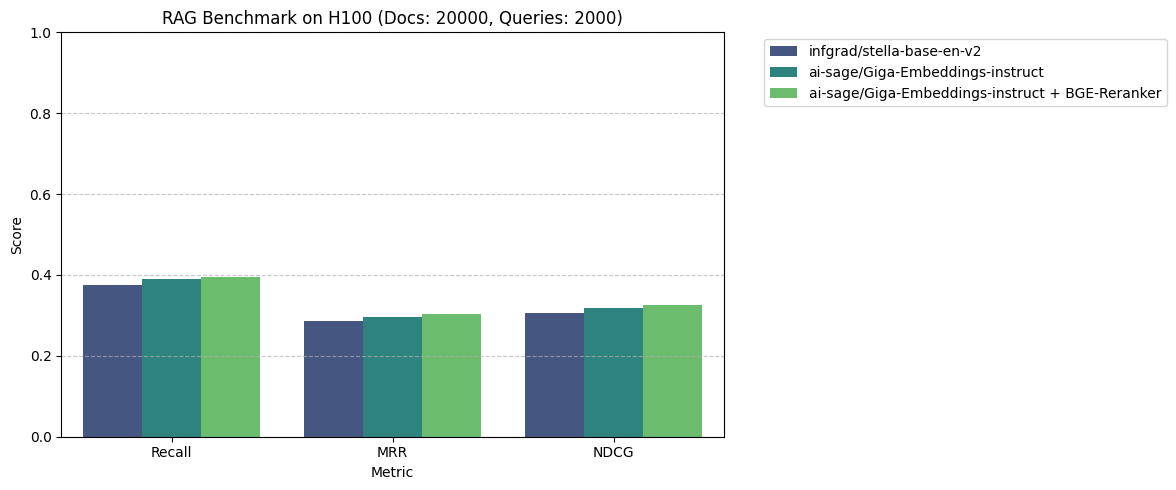

Results saved to h100_benchmark_results.csv


In [15]:
# Visualization & Reporting
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating Report...")

# Create DataFrame
df_data = []
for model, metrics in results.items():
    row = {"Model": model}
    row.update(metrics)
    df_data.append(row)

df = pd.DataFrame(df_data)

print("\nFinal Leaderboard:")
print(df.to_markdown(index=False, floatfmt=".4f"))

# Plotting
plt.figure(figsize=(12, 5))

# Melt for Seaborn
df_melted = df.melt(id_vars="Model", var_name="Metric", value_name="Score")

sns.barplot(data=df_melted, x="Metric", y="Score", hue="Model", palette="viridis")
plt.title(f"RAG Benchmark on H100 (Docs: {DOC_LIMIT}, Queries: {QUERY_LIMIT})")
plt.ylim(0, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Save results
df.to_csv("h100_benchmark_results.csv", index=False)
print("Results saved to h100_benchmark_results.csv")

In [ ]:
# Phase 3: Generative Comparison (Open/Ungated Models)
import torch
import gc
from transformers import AutoModelForCausalLM, AutoTokenizer

print("Starting Phase 3: Generative RAG Comparison")
print("NOTE: All models below run 100% LOCALLY on your GPU. No API keys required.")

# Helper to clean memory between models
def free_gpu_memory():
    gc.collect()
    torch.cuda.empty_cache()

# Text Generation Function
def generate_rag_answer(model, tokenizer, query, context_docs):
    context_text = "\n\n".join(context_docs)
    
    # Chat Template: Context + Question
    messages = [
        {"role": "system", "content": "You are a helpful assistant. Use the provided context to answer the user's question. If the answer is not in the context, say 'I don't know'."},
        {"role": "user", "content": f"Context:\n{context_text}\n\nQuestion: {query}"}
    ]
    
    input_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs, 
            max_new_tokens=256, 
            temperature=0.1, # Deterministic-ish
            do_sample=True
        )
        
    generated_ids = outputs[0][inputs.input_ids.shape[1]:]
    return tokenizer.decode(generated_ids, skip_special_tokens=True)

# Define Models to Test (Ungated, AWQ 4-bit versions for speed/memory)
# These models do NOT require a Hugging Face Login/Token.
GEN_MODELS = [
    "TheBloke/Mistral-7B-Instruct-v0.2-AWQ",  # Open/Ungated alternative to Llama
    "Qwen/Qwen2.5-7B-Instruct-AWQ"            # High performance open model
]

# We will use the 'best_model_instance' from Phase 1 to retrieve context
# Setup a small subset for generation to save time (e.g., 5-10 questions)
gen_subset = subset_queries[:5] # Kept small for quick testing
gen_results = []

for model_id in GEN_MODELS:
    print(f"\nLoading GenAI Model: {model_id}...")
    free_gpu_memory()
    
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_id)
        llm = AutoModelForCausalLM.from_pretrained(
            model_id,
            device_map="auto",
            torch_dtype=torch.float16
        )
        
        print(f"   Generating answers for {len(gen_subset)} queries...")
        for q in tqdm(gen_subset, desc=f"GenAI ({model_id.split('/')[-1]})"):
            # 1. Retrieve Context using our best Retriever
            hits = best_model_instance.retrieve(q['input'], top_k=3)
            contexts = [h.payload['output'] for h in hits]
            
            # 2. Generate Answer
            ans = generate_rag_answer(llm, tokenizer, q['input'], contexts)
            
            # 3. Store
            # Check if this question is already in results
            existing = next((item for item in gen_results if item["Question"] == q['input']), None)
            if existing:
                existing[model_id] = ans
            else:
                gen_results.append({
                    "Question": q['input'],
                    "Context_1": contexts[0][:200] + "...", # Preview
                    model_id: ans
                })
        
        del llm
        del tokenizer
        
    except Exception as e:
        print(f"Error running {model_id}: {e}")

free_gpu_memory()

# Show Comparison
df_gen = pd.DataFrame(gen_results)
print("\nGenerative RAG Comparison (Preview):")
if not df_gen.empty:
    print(df_gen[[col for col in df_gen.columns if col != "Context_1"]].head().to_markdown(index=False))
    # Save
    df_gen.to_csv("generative_comparison_results.csv", index=False)
    print("Saved generative results to 'generative_comparison_results.csv'")
else:
    print("No results generated.")